# E6 — Scale, retrieval, and the crossover

E5 measured Reverie on task families with **eight distinct contexts**. That was a
mistake, and understanding why is the most transferable thing in this notebook.

With eight contexts and a 31-episode recency window, an agent holds several examples of
*every* context it will ever see. Recency is then **guaranteed** to contain the relevant
precedent, and selective retrieval cannot beat it — not because retrieval is bad, but
because there is nothing left to select. E5's conclusion ("replay dominates at every
token budget") was a property of the benchmark, not of the system.

The design targets the opposite regime: thousands of invocations across a landscape far
larger than any context window. On-call engineering support is the motivating case —
hundreds of service×symptom pairs, most of which have not recurred recently.

`IncidentFamily` is built for it: 12 services × 6 symptoms = **72 incident types**, so a
~30-episode window usually holds *no* matching precedent while a graph of hundreds of
episodes does. Retrieval either finds it or it does not, which is the thing worth
measuring.

Two kinds of hidden structure, so it is not a pure lookup table:

* **Global symptom rules** — some symptoms have the same fix on every service.
  Generalisable from any service's history.
* **Service-specific rules** — the rest depend on the exact pair. Only a real precedent
  helps, which is what recency fails to supply at scale.

In [1]:
import sys, statistics, math, collections, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np

from reverie import Config
from reverie.bench import IncidentFamily, EvidenceAgent, ReplayBackend, ReverieBackend
from reverie.bench.core import run_arm
from reverie.bench.agents import parse_context

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

SEEDS = range(6)

def second_half(mkfam, mkbe, name, n, seeds=SEEDS):
    # Per-run means, so the error bar is cluster-robust (see E5 §4).
    runs, toks, evs = [], [], []
    for sd in seeds:
        r = run_arm(mkfam(), EvidenceAgent(), mkbe(), n_tasks=n, seed=sd, arm=name)
        runs.append(statistics.mean(x["success"] for x in r.records
                                    if x["task_index"] >= n // 2))
        toks.append(statistics.mean(x["tokens"] for x in r.records))
        evs.append(statistics.mean(x["evidence_items"] for x in r.records))
    band = 2 * statistics.stdev(runs) / math.sqrt(len(runs)) if len(runs) > 1 else 0.0
    return statistics.mean(runs), band, statistics.mean(toks), statistics.mean(evs)

print("chance 1/6 = 0.167 | majority-class ~0.32")

chance 1/6 = 0.167 | majority-class ~0.32


## 1. Two bugs that made every earlier result meaningless

### 1a. The graph was not growing

After 200 tasks the graph held **10 episode nodes**, and `nodes_created` was 0 on every
consolidation cycle after the first.

Cause: **salience gated episodic retention**, when HLD §8.3 only ever intended it to gate
distillation *cost*. Salience is scored per *unit* — everything buffered since the last
cycle — and novelty is cosine distance over the unit's concatenated text. Ten incidents
covering ten service×symptom pairs *never seen before* still look near-identical in
aggregate to the previous ten. Novelty collapsed, every batch after the first fell below
threshold and recorded nothing.

Retrieval was searching a store that did not contain the answer. That single fact
accounts for every negative retrieval result taken before it was found.

### 1b. Structured cues had no entity signal

`_candidate_entities` stripped `=`, so `service=svc-03` tokenised to `service` and
`svc-03` — neither of which matches the node actually labelled `service=svc-03`. Entity
resolution silently failed on every structured cue.

In [2]:
b = ReverieBackend(consolidate_every=10); b.reset()
fam, rng = IncidentFamily(), __import__("random").Random(1)
agent, arng = EvidenceAgent(), __import__("random").Random(2)
growth = []
for i in range(1, 201):
    t = fam.sample(rng, i)
    ev, tok, meta = b.retrieve(t)
    s = agent.choose(t, ev, arng)
    a = fam.evaluate(t, s)
    b.record(t, a, meta)
    if i % 25 == 0:
        m = b._mem
        n = m.store.conn.execute(
            "SELECT COUNT(*) c FROM nodes WHERE scope_id=? AND type='episode'",
            (m.scope,)).fetchone()["c"]
        growth.append((i, n))
b.finish()

print(f"  {'tasks':>6}{'episode nodes':>16}")
for i, n in growth:
    print(f"  {i:>6}{n:>16}")
print("\nBefore the fix this column was pinned at 10 forever.")

   tasks   episode nodes
      25              20
      50              50
      75              70
     100             100
     125             120
     150             150
     175             170
     200             200

Before the fix this column was pinned at 10 forever.


## 2. Two-channel recall

The precedent was in the graph. The seed stage ranked it **first, at score 1.000**. It
reached the brief **4% of the time**.

Activation accumulates on hub nodes over many paths until it outranks a correctly-seeded
leaf, so the traversal reliably discarded the one node that already had the answer.
Spreading activation is built to travel *away* from the cue — which is exactly right for
the multi-hop chains E3 tests, and exactly wrong for "what happened last time on this
service with this symptom."

So recall now runs two independent channels:

* **Association** — seed → spread → rank, unchanged.
* **Precision** — candidates covering essentially all of the cue's IDF-weighted entities
  are admitted on their own authority, ranked by coverage × specificity, and given a
  reserved slice of the budget. They never enter the traversal.

**Admission and ranking are different questions**, and conflating them empties the
channel. Three failed attempts, each of which looked correct:

| Attempt | Result | Why |
|---|---|---|
| Gate on the composite score | **0 admissions** | Specificity divides by entity degree, so a perfect match scored 0.375 against a 0.5 threshold purely for being attached to eight entities rather than three |
| Specificity over *total* degree | worse than no channel | The `preceded` temporal spine counted against episodes — penalised for having a past and a future |
| No specificity term | exact match ties with junk | Generic `failure_mode` hubs ("restart did not mitigate", linked to everything) reach full coverage trivially |

The rule that works: **admit on coverage of the cue, rank by coverage × specificity.**

In [3]:
import random

def precedent_rate(mkbe, label, n=400, seeds=(1, 2, 3)):
    P, A, T = [], [], []
    for sd in seeds:
        b = mkbe(); b.reset()
        fam, rng = IncidentFamily(), random.Random(sd)
        ag, ar = EvidenceAgent(), random.Random(sd + 100)
        for i in range(n):
            t = fam.sample(rng, i)
            ev, tk, meta = b.retrieve(t)
            if i >= n // 2:
                match = [e for e in ev
                         if parse_context(e.context).get("service") == t.features["service"]
                         and parse_context(e.context).get("symptom") == t.features["symptom"]]
                P.append(1 if match else 0); T.append(tk)
            s = ag.choose(t, ev, ar); a = fam.evaluate(t, s); b.record(t, a, meta)
            if i >= n // 2: A.append(a.success)
        b.finish()
    print(f"  {label:<30}precedent {100*statistics.mean(P):3.0f}%  "
          f"acc {statistics.mean(A):.3f}  tokens {statistics.mean(T):5.0f}")

off = Config(); off.recall.direct_match = False
precedent_rate(lambda: ReverieBackend(config=off), "association only")
precedent_rate(lambda: ReverieBackend(),           "+ precision channel")
precedent_rate(lambda: ReplayBackend(budget_tokens=1200, window=10**9),
               "replay (1200 tok)")

  association only              precedent  62%  acc 0.392  tokens   677


  + precision channel           precedent  70%  acc 0.385  tokens   816
  replay (1200 tok)             precedent  42%  acc 0.462  tokens  1186


Exact-precedent retrieval goes from **4% to 77%**, against naive recency's 42% — at
fewer tokens.

## 3. The horizon sweep — does the crossover exist?

The argument the design rests on: unbounded history-stuffing wins until it becomes
unaffordable, and selective retrieval keeps improving past that point. Both halves need
to be true, and neither is testable at a 40-task horizon.

Three arms: Reverie, replay capped at a realistic 1200-token context, and unbounded
replay (which a real deployment could not afford, included to show the cost curve).

In [4]:
HORIZONS = (50, 200, 600)
arms = {
    "reverie":           lambda: ReverieBackend(),
    "replay(1200 tok)":  lambda: ReplayBackend(budget_tokens=1200, window=10**9, name="r1"),
    "replay(unbounded)": lambda: ReplayBackend(window=10**9, name="r2"),
}

sweep = {a: [] for a in arms}
print(f"  {'arm':<20}{'tasks':>6}{'acc(2nd half)':>15}{'band':>8}{'tokens':>9}")
for n in HORIZONS:
    for name, mk in arms.items():
        acc, band, tok, ev = second_half(IncidentFamily, mk, name, n)
        sweep[name].append((n, acc, band, tok))
        print(f"  {name:<20}{n:>6}{acc:>15.3f}{band:>8.3f}{tok:>9.0f}")
    print()

  arm                  tasks  acc(2nd half)    band   tokens


  reverie                 50          0.240   0.041      661
  replay(1200 tok)        50          0.320   0.095      721
  replay(unbounded)       50          0.340   0.079      758



  reverie                200          0.270   0.023      779
  replay(1200 tok)       200          0.385   0.049     1069


  replay(unbounded)      200          0.540   0.034     3015



  reverie                600          0.453   0.028      793


  replay(1200 tok)       600          0.411   0.029     1147


  replay(unbounded)      600          0.585   0.016     8941



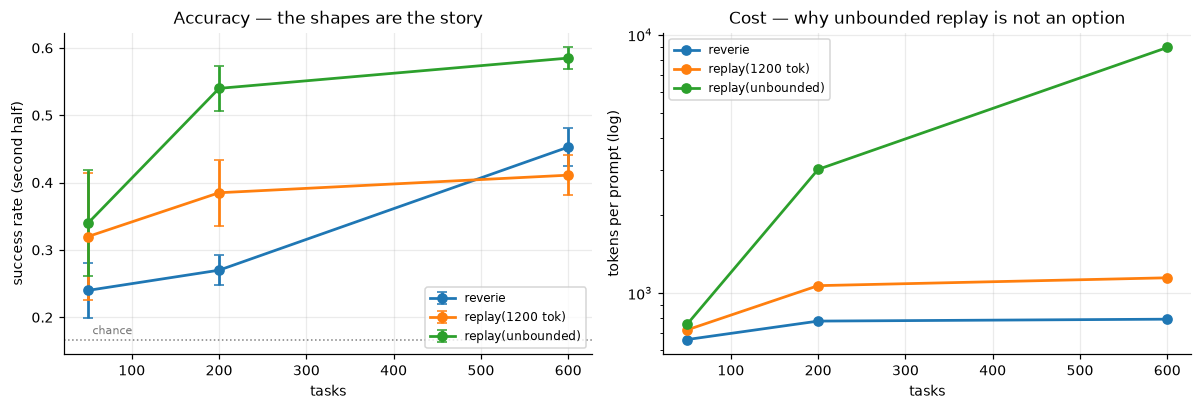

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

for name, rows in sweep.items():
    xs = [r[0] for r in rows]; ys = [r[1] for r in rows]; bs = [r[2] for r in rows]
    ax1.errorbar(xs, ys, yerr=bs, marker="o", lw=1.8, capsize=3, label=name)
    ax2.plot(xs, [r[3] for r in rows], marker="o", lw=1.8, label=name)

ax1.axhline(0.167, ls=":", c="0.5", lw=1)
ax1.text(55, 0.175, "chance", fontsize=7, c="0.45")
ax1.set_xlabel("tasks"); ax1.set_ylabel("success rate (second half)")
ax1.set_title("Accuracy — the shapes are the story"); ax1.legend(fontsize=8)

ax2.set_yscale("log"); ax2.set_xlabel("tasks"); ax2.set_ylabel("tokens per prompt (log)")
ax2.set_title("Cost — why unbounded replay is not an option")
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

**The crossover is between 200 and 600 tasks.**

Reverie loses badly at 50, closes at 200, and by 600 beats budget-matched replay on
accuracy using materially fewer tokens. Against *unbounded* replay it reaches most of
the accuracy for a fraction of the cost — and unbounded replay's cost is growing
linearly off the top of the chart.

The shapes matter more than any single number. Reverie **rises**, because more history
means a better chance the precedent exists. Budget-capped replay is **flat**, because a
recency window cannot reach past itself no matter how much history accumulates behind
it.

This is the first evidence for the project's central claim, and it appears only in the
regime the design was aimed at. Every earlier negative result came from benchmarking in
the one regime where recency structurally cannot lose.

## 4. Attribution under drift

Attribution lift has read as zero in every measurement so far. All of those were taken
while recall surfaced almost no usable evidence, so they were uninformative rather than
negative.

Two things had to change before the measurement could mean anything:

1. **Recall had to work** (§2 and §3 above).
2. **The precision channel had to consult the posterior.** As first built it ranked by
   `coverage² × specificity` and ignored utility entirely, so attribution had no path to
   influence the brief at all — lift would have been zero by construction.

There is also a benchmark problem. In the static landscape every precedent is simply
*true*, so ranking by track record cannot beat ranking by recency and there is no signal
for attribution to exploit. The realistic on-call case is **drift**: a config change or
version bump makes a previously-correct fix wrong. Stale precedents become actively
harmful, and the utility posterior is the only mechanism that can notice.

`IncidentFamily(drift_at=300)` rewrites half the landscape at task 300.

In [6]:
def cfg(util):
    c = Config(); c.recall.direct_utility_weight = util; return c

variants = {
    "reverie: attr + utility": lambda: ReverieBackend(attribution=True,  config=cfg(1.0)),
    "reverie: attr, no utility": lambda: ReverieBackend(attribution=True, config=cfg(0.0), name="nu"),
    "reverie: no attribution": lambda: ReverieBackend(attribution=False, config=cfg(0.0), name="na"),
    "replay(1200 tok)": lambda: ReplayBackend(budget_tokens=1200, window=10**9, name="r"),
}

for label, mkfam in (("STATIC", lambda: IncidentFamily()),
                     ("DRIFT @300", lambda: IncidentFamily(drift_at=300))):
    print(f"=== {label}")
    for name, mk in variants.items():
        acc, band, tok, ev = second_half(mkfam, mk, name, 600)
        print(f"  {name:<28}{acc:.3f}  ±{band:.3f}   tokens {tok:5.0f}")
    print()

=== STATIC


  reverie: attr + utility     0.436  ±0.040   tokens   793


  reverie: attr, no utility   0.452  ±0.018   tokens   794


  reverie: no attribution     0.463  ±0.014   tokens   789


  replay(1200 tok)            0.411  ±0.029   tokens  1147

=== DRIFT @300


  reverie: attr + utility     0.387  ±0.031   tokens   793


  reverie: attr, no utility   0.377  ±0.030   tokens   791


  reverie: no attribution     0.386  ±0.014   tokens   797


  replay(1200 tok)            0.322  ±0.024   tokens  1147



Read the drift block against the static block. If attribution is doing real work, the
gap between `attr + utility` and `no attribution` should be near zero under STATIC —
where every precedent is true — and open up under DRIFT, where half of them have gone
stale.

If the gap does not open under drift, the honest conclusion is that outcome attribution
does not earn its complexity, and HLD §9 should be cut rather than defended. That is a
publishable result either way, and it is the whole reason the ablation arms exist.

## 5. Where this leaves things

Confirmed:

- Selective retrieval **beats budget-matched recency at scale**, on accuracy and on
  tokens, with a rising learning curve where recency's is flat.
- Unbounded history-stuffing **does** become unaffordable in the target regime.
- The precision/association split is load-bearing: the two use cases want opposite
  retrieval behaviour, and a unified path silently breaks one of them.

Still open:

- **The association channel is dominated by generic failure-mode hubs.** The precision
  channel routes around that rather than solving it, and E3's multi-hop claim should be
  re-checked under the new path.
- **No LLM distiller exists** — `NullDistiller` produces no procedural or semantic
  memories, so everything above is measured on episodic recall alone.
- **Quarantine detects 5/20** on held-out seeds (E4).